# Cách Dự báo Time-Series sử dụng SARIMA



## Giới thiệu



Trong một trong các bài viết trước, chúng ta đã đề cập đến có lẽ mô hình forecasting (dự báo) nổi tiếng nhất, Autoregressive Integrated Moving Average hay còn được biết đến là ARIMA. Tuy nhiên, một nhược điểm của mô hình này là nó thiếu nhận thức về bất kỳ seasonality (tính mùa vụ) nào. Đây là nơi mô hình Seasonal Autoregressive Integrated Moving Average, hay SARIMA, xuất hiện. Trong bài viết này, chúng ta sẽ đi sâu vào lý thuyết và ý tưởng chính đằng sau mô hình SARIMA và cách implement (triển khai) nó trong Python.


## SARIMA là gì




### Tổng quan


SARIMA là một phần mở rộng của mô hình ARIMA thông thường bằng cách thêm một thành phần seasonality (tính mùa vụ) vào mô hình. Điều này cho phép chúng ta nắm bắt tốt hơn các ảnh hưởng seasonal mà mô hình ARIMA thông thường không cho phép.


### Lý thuyết


Mô hình ARIMA cổ điển có ba thành phần: Autoregressive, Integrated (differencing), và Moving-Average. Chúng sau đó được kết hợp tuyến tính để tạo thành mô hình:


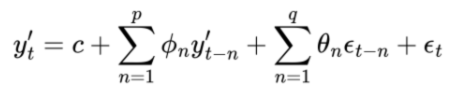
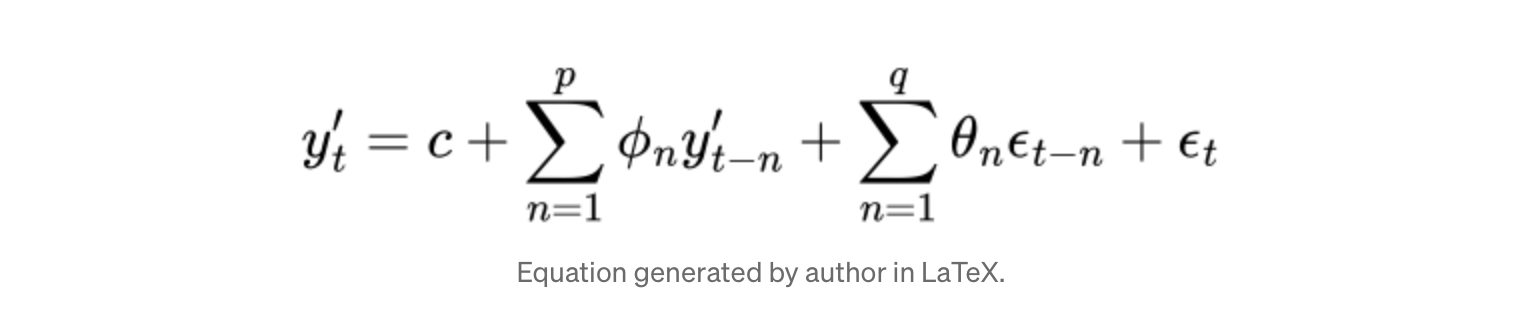

Trong đó:
- y': time series đã differenced, số lần differencing được áp dụng được ký hiệu là d
- ϕ: coefficients (hệ số) của các thành phần autoregressive (lags - độ trễ)
- p: số lượng các thành phần autoregressive
- ε: forecast error terms (sai số dự báo), các thành phần moving-average
- θ: coefficients của các lagged forecast errors
- q: số lượng các thành phần lagged error

Mô hình thường được viết gọn là ARIMA(p, d, q) trong đó p, d, và q đề cập đến order (bậc) của các thành phần autoregressors, differencing và moving-average tương ứng.


SARIMA thêm một thành phần seasonality vào mỗi yếu tố của phương trình ARIMA để tạo ra SARIMA(p, d, q)(P, D, Q)m:


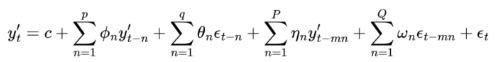
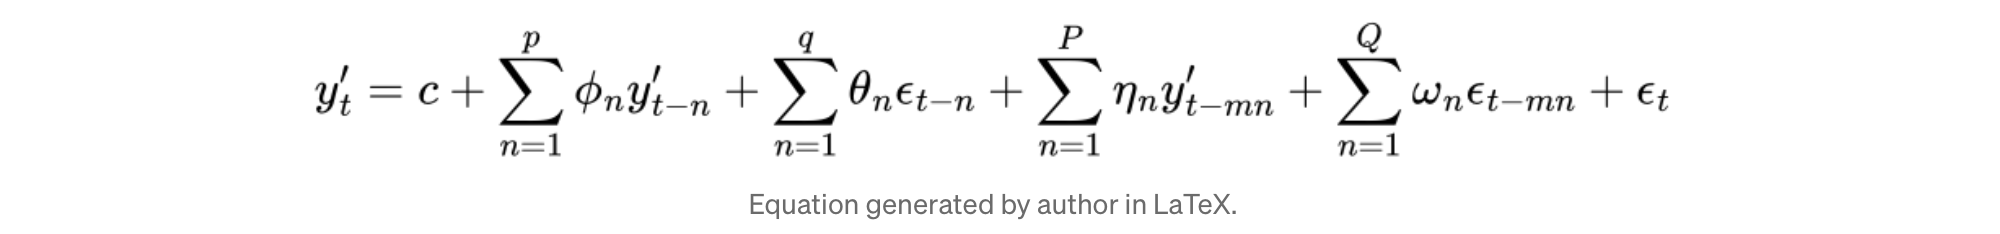

Trong đó:
- y': time series đã differenced, thông qua cả regular (thông thường), d, và seasonal (mùa vụ), D, differencing
- P: số lượng seasonal auto-regressors
- ω: coefficients (hệ số) của các thành phần seasonal autoregressive
- Q: số lượng các thành phần seasonal moving-average
- η: coefficients của các seasonal forecast errors
- m: độ dài của season (mùa)


### Yêu cầu


Giống như mô hình ARIMA gốc, mô hình SARIMA cần có dữ liệu stationary (dừng) để mô hình hóa và dự báo time series. Một time series stationary không biểu hiện bất kỳ trend (xu hướng) dài hạn hoặc seasonality (tính mùa vụ) rõ ràng nào, các thuộc tính thống kê của nó, như mean (trung bình) và variance (phương sai), vẫn không đổi theo thời gian.

Để tạo ra một time series stationary, chúng ta cần ổn định mean và variance. Mean có thể được ổn định thông qua differencing và số lần differencing được áp dụng là d hoặc D trong trường hợp seasonal differencing. Variance có thể được ổn định thông qua các biến đổi như logarithmic và Box-Cox transform, điều này làm cho các biến động seasonal xảy ra ở mức tương tự mỗi mùa.


### Lựa chọn Order (Bậc)


Sau khi time series đã stationary (dừng), chúng ta sau đó cần suy ra các orders (bậc) tốt nhất, (p, d, q) và (P, D, Q)m, cho mô hình của chúng ta. Đơn giản nhất để tính toán là seasonal, D, và regular differencing, d. Điều này có thể được suy ra thông qua kiểm định thống kê Augmented Dickey-Fuller (ADF) để suy ra liệu một time series có stationary hay không.

Các orders autoregressive và moving-average (forecast errors) (p, q, P, Q) có thể được tính toán bằng cách phân tích partial autocorrelation function (PACF) và autocorrelation function tương ứng. Ý tưởng đằng sau kỹ thuật này là vẽ correlogram của các giá trị autoregressor và moving-average và suy ra những cái nào có ý nghĩa thống kê. Những cái có ý nghĩa cho thấy rằng chúng có tác động đáng kể đến forecast (dự báo).

Các correlograms này cũng sẽ cho phép chúng ta quan sát seasonal pattern (mẫu mùa vụ) nếu có, vì chúng ta có thể thấy các peaks (đỉnh) ở một số lags bội số nhất định. Ví dụ, một SARIMA(0,0,0)(1,0,0)4 sẽ cho thấy exponential decay (suy giảm hàm mũ) trong các lags cho ACF nhưng một spike (đột biến) có ý nghĩa ở lag 4 trong PACF. Nếu dữ liệu được đánh chỉ số theo tháng, thì đây sẽ là một ví dụ về seasonality theo quý.


### Ước lượng


Bước cuối cùng là tính toán các coefficients (hệ số) tương ứng cho các orders này. Phương pháp phổ biến nhất là sử dụng Maximum Likelihood Estimation (MLE - Ước lượng hợp lý cực đại) để ước lượng các coefficients đối với một phân phối xác suất giả định nào đó, thường là phân phối chuẩn, để tính toán coefficient nào có khả năng nhất tạo ra dữ liệu đó. Vì time series là stationary và có các thuộc tính thống kê không đổi, chúng ta có thể nói rằng nó thuộc về một phân phối xác suất nào đó cho phép chúng ta sử dụng MLE. Đây là lý do tại sao stationarity là yêu cầu chính cho SARIMA.


## Hướng dẫn Python




### Dữ liệu


In [1]:
# Import các package
import plotly.express as px
import pandas as pd

# Đọc dữ liệu
data = pd.read_csv('AirPassengers.csv')
data['Month'] = pd.to_datetime(data['Month'])


def plot_passenger_volumes(df: pd.DataFrame,
                           y: str) -> None:
    """Hàm chung để vẽ dữ liệu hành khách."""

    fig = px.line(df, x='Month', y=y, labels={'Month': 'Date'})
    fig.update_layout(template="simple_white", font=dict(size=18), title_text='Hành khách Hàng không',
                      width=650, title_x=0.5, height=400)

    return fig.show()


# Vẽ biểu đồ dữ liệu hành khách hàng không
plot_passenger_volumes(df=data, y='#Passengers')


Có một trend (xu hướng) và seasonality (tính mùa vụ) rõ ràng, vì vậy dữ liệu không stationary (dừng) vì mean (trung bình) và variance (phương sai) đang thay đổi theo thời gian. Do đó, chúng ta cần áp dụng differencing và biến đổi Box-Cox để làm cho chuỗi của chúng ta stationary theo yêu cầu của SARIMA:


In [2]:
# Import các package
from scipy.stats import boxcox

# Làm cho dữ liệu stationary
data['Passengers_Boxcox'], lam = boxcox(data['#Passengers'])
data["Passenger_diff"] = data["Passengers_Boxcox"].diff()
data.dropna(inplace=True)

# Vẽ biểu đồ dữ liệu hành khách stationary
plot_passenger_volumes(df=data, y='Passenger_diff')


Dữ liệu bây giờ trông đủ stationary (dừng).



### Mô hình hóa


Bây giờ chúng ta sẽ sử dụng các correlogram ACF và PACF để suy ra các orders cho các thành phần autoregressive và moving-average:


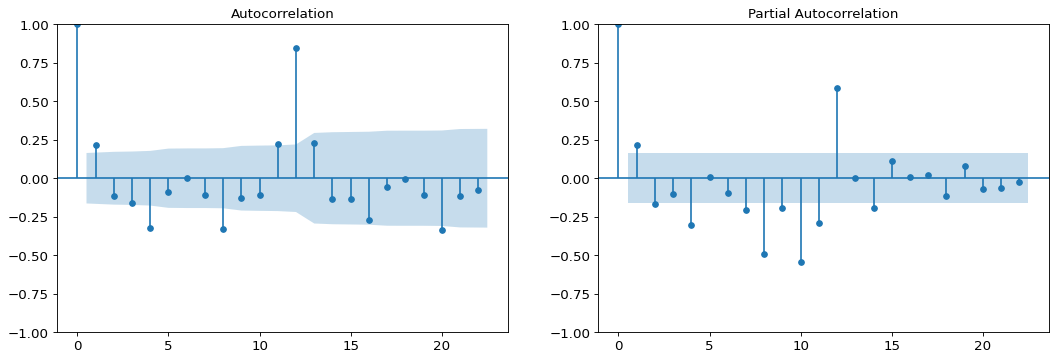

In [3]:
# Import các package
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

# Vẽ acf và pacf
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), dpi=80)
plot_acf(data['Passenger_diff'], ax=ax1)
plot_pacf(data['Passenger_diff'], method='ywm', ax=ax2)
ax1.tick_params(axis='both', labelsize=12)
ax2.tick_params(axis='both', labelsize=12)
plt.show()


Chúng ta đã quan sát rằng chuỗi của chúng ta có yearly seasonality (tính mùa vụ hàng năm), m=12, nhưng các biểu đồ trên xác nhận điều này vì chúng ta có các spikes (đột biến) lớn ở lags thứ 12. Các lags cũng có ý nghĩa đến khoảng ~lag thứ 10 cho cả hai biểu đồ. Nhìn chung, điều này cho thấy rằng một mô hình SARIMA(10, 1, 10)(1, 1, 1)12 nên phù hợp.

Bây giờ, hãy fit mô hình bằng cách sử dụng class ARIMA từ statsmodels và tạo ra các forecasts (dự báo). May mắn thay, class này thực hiện differencing cho chúng ta, vì vậy chúng ta chỉ cần truyền time series đã biến đổi Box-Cox:


In [11]:
# Import các package
from scipy.special import inv_boxcox
from statsmodels.tsa.arima.model import ARIMA

# Chia train và test
train = data.iloc[:-int(len(data) * 0.2)]
test = data.iloc[-int(len(data) * 0.2):]

# Xây dựng mô hình ARIMA
model = ARIMA(train['Passengers_Boxcox'], order=(10, 1, 10),
              seasonal_order=(1, 1, 1, 12)).fit()
boxcox_forecasts = model.forecast(len(test))
forecasts = inv_boxcox(boxcox_forecasts, lam)


c:\Users\DUYEN\anaconda3\envs\jepx\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

c:\Users\DUYEN\anaconda3\envs\jepx\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

c:\Users\DUYEN\anaconda3\envs\jepx\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

c:\Users\DUYEN\anaconda3\envs\jepx\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.

c:\Users\DUYEN\a

### Kết quả


Cuối cùng, chúng ta sẽ vẽ các forecasts (dự báo):


In [12]:
# Import các package
import plotly.graph_objects as go

def plot_forecasts(forecasts: list[float], title: str) -> None:
    """Hàm để vẽ các forecasts."""
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=train['Month'], y=train['#Passengers'], name='Train'))
    fig.add_trace(go.Scatter(x=test['Month'], y=test['#Passengers'], name='Test'))
    fig.add_trace(go.Scatter(x=test['Month'], y=forecasts, name='Forecast'))
    fig.update_layout(template="simple_white", font=dict(size=18), title_text=title,
                      width=650, title_x=0.5, height=400, xaxis_title='Ngày',
                      yaxis_title='Hành khách')

    return fig.show()


# Vẽ biểu đồ các forecasts
plot_forecasts(forecasts, 'SARIMA')


Các forecasts (dự báo) của SARIMA có vẻ đã làm khá tốt!

